In [1]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. tensorflow v2.10에서 v1사용하기

In [60]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior() # v2를 비활성화하고 v2 활성화
import numpy as np
import pandas as pd

## Tensorflow
- 데이터 흐름 그래프 (tensor 객체의 흐름)
- 이 그래프는 node(상수, 변수, 연산)와 edge로 구성
- sess = tf.Session으로 실행
- sess.run()을 통해 값을 확인

In [4]:
# tensor = data(상수, 변수)와 연산
node1 = tf.constant('Hello, Tensorflow')
sess = tf.Session()
print(sess.run(node1))

b'Hello, Tensorflow'


In [5]:
node1 = tf.constant(10, dtype=tf.float16)
node2 = tf.constant(20, dtype=tf.float16)
node3 = tf.add(node1, node2)
sess = tf.Session()
print(sess.run([node1, node2, node3]))

[10.0, 20.0, 30.0]


In [7]:
# 타입 변경
node1 = tf.constant(np.array([1,2,3]), dtype=tf.int16)
node2 = tf.cast(node1, dtype=tf.float32)
sess = tf.Session()
sess.run([node1, node2])

[array([1, 2, 3], dtype=int16), array([1., 2., 3.], dtype=float32)]

In [8]:
# 평균값 계산 : tf.reduce_mean()
data = np.array([1.,2.,3.])
tensor = tf.reduce_mean(data)
sess = tf.Session()
sess.run(tensor)

2.0

In [11]:
# 랜덤값을 갖는 tensor
a = tf.random_normal([2]) # 평균0, 표준편차 1인 난수 실수 2개 (정규분포 이루는 난수)
b = tf.random_normal([1])
sess = tf.Session()
sess.run([a,b])

[array([-0.1951313 ,  0.91458863], dtype=float32),
 array([1.7496369], dtype=float32)]

In [13]:
w = tf.Variable(tf.random.normal([1]))
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w변수의 난수 초기화
sess.run(w)

array([-0.8783929], dtype=float32)

# 2. tensorflow v1을 이용한 linear regression을 구현
## 2.1 입력(독립)변수 x가 1개, 타겟(종속)변수 y가 1개

In [30]:
x = np.array([1,2,3])
y = np.array([2,3,4])
# weight와 bias(처음엔 랜덤값으로 셋팅, 학습과정에서 변경)
W = tf.Variable(tf.random.normal([1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')
# hypothesis : 예측값
H = W*x + b
# cost function(손실함수 = mse; 최소제곱법)
cost = tf.reduce_mean(tf.square(H-y))
'''
학습목적 : cost가 최소가 되는 W, b를 찾아내는 것
cost는 2차함수이므로 곡선그래프. 곡선위 미분값이 줄어드는 방향으로 학습(경사하강)
=> GradientdescentOptimizer
'''
optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.01)
train = optimizer.minimize(cost)
# Session 생성
sess = tf.Session()
# W, b 변수 노드 초기화
sess.run(tf.global_variables_initializer())
# 5000번 학습 (v2에서는 fit함수)
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, w, b])
    if step%200 == 0 :
        print('{}번째 cost: {}, w: {}, b: {}'.format(step, cost_val, W_val, b_val))

0번째 cost: 4.573808670043945, w: [-0.38742274], b: [-0.72376263]
200번째 cost: 0.1092761978507042, w: [-0.38742274], b: [0.12932152]
400번째 cost: 0.04172701761126518, w: [-0.38742274], b: [0.46197346]
600번째 cost: 0.015933411195874214, w: [-0.38742274], b: [0.6675323]
800번째 cost: 0.006084159482270479, w: [-0.38742274], b: [0.7945551]
1000번째 cost: 0.002323242835700512, w: [-0.38742274], b: [0.8730473]
1200번째 cost: 0.0008871189202181995, w: [-0.38742274], b: [0.9215512]
1400번째 cost: 0.0003387540637049824, w: [-0.38742274], b: [0.951523]
1600번째 cost: 0.00012934691039845347, w: [-0.38742274], b: [0.97004473]
1800번째 cost: 4.9390964704798535e-05, w: [-0.38742274], b: [0.9814895]
2000번째 cost: 1.8860991986002773e-05, w: [-0.38742274], b: [0.9885614]
2200번째 cost: 7.202650976978475e-06, w: [-0.38742274], b: [0.9929313]
2400번째 cost: 2.750275598373264e-06, w: [-0.38742274], b: [0.99563193]
2600번째 cost: 1.0506811349841882e-06, w: [-0.38742274], b: [0.99730027]
2800번째 cost: 4.017506398668047e-07, w: [-0.

In [22]:
sess.run([W,b])

[array([0.9999891], dtype=float32), array([1.0000248], dtype=float32)]

In [23]:
W_, b_ = sess.run([W,b])
W_[0], b_[0]

(0.9999891, 1.0000248)

In [24]:
def predict(x):
    return W_[0]*x+b_[0]

In [26]:
input_x = int(input('입력값은?'))
print('예측값은 ', predict(input_x))

입력값은?4
예측값은  4.999981164932251


## 2.2 predict를 위한 placeholder이용
- placeholder : 텐서플로우 외부에서 데이터를 입력받는 노드

In [29]:
# x = np.arry([1,2,3])
x = tf.placeholder(tf.float16)
H = 1*x+1
sess = tf.Session()
sess.run(H, feed_dict={x:5})
sess.run(H, feed_dict={x:np.array([1,2,3])})

array([2., 3., 4.], dtype=float16)

In [33]:
# H = 2x+1
x_data = np.array([1,2,3,5,8])
y_data = np.array([3,5,7,11,17])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W,b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothsis (예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 5000번 학습
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data, y:y_data})
    if step%200 == 0:
        print('{}번째 cost: {}, w: {}, b: {}'.format(step, cost_val, W_val, b_val))

0번째 cost: 24.161340713500977, w: [1.4166186], b: [0.7961627]
200번째 cost: 0.00024917986593209207, w: [2.0053682], b: [0.9713069]
400번째 cost: 2.450958709232509e-05, w: [2.0016837], b: [0.99100137]
600번째 cost: 2.411992454653955e-06, w: [2.000528], b: [0.99717736]
800번째 cost: 2.373957102008717e-07, w: [2.0001657], b: [0.99911433]
1000번째 cost: 2.33145893702158e-08, w: [2.000052], b: [0.9997221]
1200번째 cost: 2.293472745051872e-09, w: [2.0000165], b: [0.9999129]
1400번째 cost: 2.36707375922407e-10, w: [2.0000055], b: [0.999972]
1600번째 cost: 3.1877788603251744e-11, w: [2.0000021], b: [0.99998945]
1800번째 cost: 2.060005464821213e-11, w: [2.0000017], b: [0.99999213]
2000번째 cost: 2.060005464821213e-11, w: [2.0000017], b: [0.99999213]
2200번째 cost: 2.060005464821213e-11, w: [2.0000017], b: [0.99999213]
2400번째 cost: 2.060005464821213e-11, w: [2.0000017], b: [0.99999213]
2600번째 cost: 2.060005464821213e-11, w: [2.0000017], b: [0.99999213]
2800번째 cost: 2.060005464821213e-11, w: [2.0000017], b: [0.99999213

In [34]:
# 예측하기
sess.run(H, feed_dict={x:5})

array([11.000001], dtype=float32)

In [35]:
sess.run(H, feed_dict={x:np.array([5,6,7])})

array([11.000001, 13.000002, 15.000004], dtype=float32)

In [39]:
type([5,6,7]), type(np.array([5,6,7]))

(list, numpy.ndarray)

# 2.3 scale이 다른 데이터의 linear regression 구현 (scale 조정 x)

In [41]:
# H = 2x+1
x_data = np.array([1,2,3,5,8])
y_data = np.array([3,15,68,80,95])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W,b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothsis (예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 5000번 학습
for step in range(1001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data, y:y_data})
    if step%200 == 0:
        print('{}번째 cost: {}, w: {}, b: {}'.format(step, cost_val, W_val, b_val))

0번째 cost: 3508.753173828125, w: [6.4401855], b: [-0.3838833]
200번째 cost: 265.6599426269531, w: [13.231541], b: [1.803196]
400번째 cost: 265.61529541015625, w: [13.1795845], b: [2.0809002]
600번째 cost: 265.6108703613281, w: [13.16329], b: [2.1679964]
800번째 cost: 265.61041259765625, w: [13.158179], b: [2.1953118]
1000번째 cost: 265.61041259765625, w: [13.156576], b: [2.203878]


In [42]:
# cost값이 멈춤 : local 최소값

## 2.4 scale이 다른 데이터의 linear regression을 구현(조정 o)
### scale을 맞추기 : 모든 데이터를 일정 범위내로 조정
- normalization (정규화): 0~1로 조정
                       X - Xmin
      normalization = ____________
                       Xmax - Xmin
          * 위의 식을 써도 되지만 라이브러리를 사용(sklearn.preprocessing.MinMaxScaler이용)
- standardization (표준화): 평균 0, 표준편차 1로 조정
                         X - Xmean(평균)
      standardization = ________________
                           Xstd (표준편차)
          * 위의 식을 써도 되지만 라이브러리를 사용(sklearn.preprocessing.StandardScaler이용)

In [49]:
# 라이브러리를 쓰지 않고 정규화
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
scaled_x_data = (x_data - x_data.min())/(x_data.max() - x_data.min())
scaled_y_data = (y_data - y_data.min())/(y_data.max() - y_data.min())
print(scaled_x_data,'\n', scaled_y_data)

[0.         0.11111111 0.44444444 0.77777778 1.        ] 
 [0.         0.13043478 0.70652174 0.83695652 1.        ]


In [73]:
# 라이브러리를 이용한 정규화 (MinMaxScaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1,1)
y_data = np.array([3,15,68,80,95]).reshape(-1,1)
# np.column_stack([x_data, y_data])
from sklearn.preprocessing import MinMaxScaler
scaler_x = MinMaxScaler() # x_data를 정규화시킬 객체
# scaler_x.fit(x_data)
# scaled_x_data = scaler_x.transform(x_data)
scaled_x_data = scaler_x.fit_transform(x_data)
scaler_y = MinMaxScaler() # y_data를 정규화시킬 객체
scaled_y_data = scaler_y.fit_transform(y_data)
np.column_stack([x_data, y_data, scaled_x_data, scaled_y_data])

array([[ 1.        ,  3.        ,  0.        ,  0.        ],
       [ 2.        , 15.        ,  0.11111111,  0.13043478],
       [ 5.        , 68.        ,  0.44444444,  0.70652174],
       [ 8.        , 80.        ,  0.77777778,  0.83695652],
       [10.        , 95.        ,  1.        ,  1.        ]])

In [74]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W,b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothsis (예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 12000번 학습
for step in range(12000):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data, y:scaled_y_data})
    if step%500 == 0:
        print('{}번째 cost: {}, w: {}, b: {}'.format(step, cost_val, W_val, b_val))

0번째 cost: 0.612799882888794, w: [1.1231313], b: [0.7666885]
500번째 cost: 0.01044379360973835, w: [0.94559354], b: [0.09733973]
1000번째 cost: 0.009919585660099983, w: [0.9884693], b: [0.07469078]
1500번째 cost: 0.009868691675364971, w: [1.0018286], b: [0.06763465]
2000번째 cost: 0.009863755665719509, w: [1.0059907], b: [0.06543614]
2500번째 cost: 0.009863274171948433, w: [1.0072877], b: [0.06475123]
3000번째 cost: 0.009863226674497128, w: [1.0076914], b: [0.06453823]
3500번째 cost: 0.009863225743174553, w: [1.0078124], b: [0.06447316]
4000번째 cost: 0.009863222017884254, w: [1.0078529], b: [0.06445174]
4500번째 cost: 0.009863224811851978, w: [1.0078539], b: [0.06445099]
5000번째 cost: 0.009863224811851978, w: [1.0078539], b: [0.06445099]
5500번째 cost: 0.009863224811851978, w: [1.0078539], b: [0.06445099]
6000번째 cost: 0.009863224811851978, w: [1.0078539], b: [0.06445099]
6500번째 cost: 0.009863224811851978, w: [1.0078539], b: [0.06445099]
7000번째 cost: 0.009863224811851978, w: [1.0078539], b: [0.06445099]
750

In [75]:
# 예측 : 모델에 sclae 조정된 값으로 예측 => scale조정된 y값
scaled_input = scaler_x.transform(np.array([[4],
                                           [7]]))
print('모델 예측을 위한 입력 :', scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델 예측 결과 :', scaled_output, sep='\n')
print('결과 ', scaler_y.inverse_transform(scaled_output), sep='\n')

모델 예측을 위한 입력 :
[[0.33333333]
 [0.66666667]]
모델 예측 결과 :
[[0.4004023]
 [0.7363536]]
결과 
[[39.837013]
 [70.74453 ]]


In [76]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)

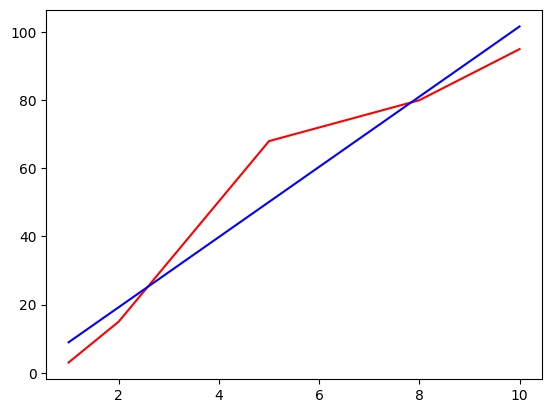

In [77]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

In [82]:
# 라이브러리를 사용하여 표준화(standardscaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1,1)
y_data = np.array([3,15,68,80,95]).reshape(-1,1)
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler() # x_data를 표준화할 객체
scaler_y = StandardScaler() # y_data를 표준화할 객체
scaled_x_data = scaler_x.fit_transform(x_data)
scaled_y_data = scaler_y.fit_transform(y_data)
print(np.column_stack([x_data, y_data]))
print(np.column_stack([scaled_x_data, scaled_y_data]))

# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W,b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothsis (예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 12000번 학습
for step in range(12000):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data, y:scaled_y_data})
    if step%500 == 0:
        print('{}번째 cost: {}, w: {}, b: {}'.format(step, cost_val, W_val, b_val))

[[ 1  3]
 [ 2 15]
 [ 5 68]
 [ 8 80]
 [10 95]]
[[-1.22474487 -1.34819316]
 [-0.93313895 -1.01936556]
 [-0.05832118  0.43295634]
 [ 0.81649658  0.76178394]
 [ 1.39970842  1.17281844]]
0번째 cost: 2.4903039932250977, w: [0.46039817], b: [-1.4400252]
500번째 cost: 0.06268569082021713, w: [0.9681291], b: [-5.9061287e-05]
1000번째 cost: 0.06268571317195892, w: [0.96814847], b: [-2.2081583e-08]
1500번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
2000번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
2500번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
3000번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
3500번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
4000번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
4500번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
5000번째 cost: 0.06268571317195892, w: [0.96814847], b: [-1.671717e-08]
5500번째 cost: 0.06268571317195892, w: [0.96814847], b: [

모델 예측을 위한 입력 :
[[-0.34992711]
 [ 0.52489066]]
모델 예측 결과 :
[[-0.33878142]
 [ 0.5081721 ]]
결과 
[[39.836754]
 [70.74487 ]]


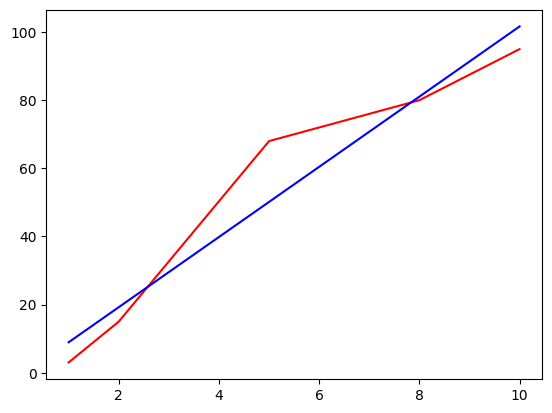

In [80]:
# 예측 : 모델에 sclae 조정된 값으로 예측 => scale조정된 y값
scaled_input = scaler_x.transform(np.array([[4],
                                           [7]]))
print('모델 예측을 위한 입력 :', scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델 예측 결과 :', scaled_output, sep='\n')
print('결과 ', scaler_y.inverse_transform(scaled_output), sep='\n')

# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)

import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

# 2.5 입력(독립)변수 x가 3개, 타겟(종속)변수 y가 1개(csv=>array)

In [4]:
# 방법 1: csv -> array
import numpy as np
# data = np.loadtxt('data/pima-indians-diabetes.csv', delimiter=',', encoding='utf-8')
data = np.genfromtxt('data/ozone.csv', delimiter=',', skip_header=1, 
                                         missing_values='NA', filling_values=np.nan)
data[:5]

array([[ 41. , 190. ,   7.4,  67. ,   5. ,   1. ],
       [ 36. , 118. ,   8. ,  72. ,   5. ,   2. ],
       [ 12. , 149. ,  12.6,  74. ,   5. ,   3. ],
       [ 18. , 313. ,  11.5,  62. ,   5. ,   4. ],
       [  nan,   nan,  14.3,  56. ,   5. ,   5. ]])

In [30]:
# 방법 1: csv파일 -> 데이터프레임 -> 결측치처리 -> 넘파이배열 -> 머신러닝
# 1. csv를 데이터프레임으로 읽기
import pandas as pd
data = pd.read_csv('data/ozone.csv', encoding='utf-8')
data.info()       # Ozone, Solar.R 열에만 결측치
data.isna().sum() # 열별 결측치 갯수

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 7.3 KB


Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [31]:
# 2. 결측치 처리
# 결측치 처리 방법1 : 결측치가 있는 행을 제거
# data.dropna(how='any', axis=0, inplace=True).shape
# 결측치 처리 방법2 : 결측치 대체(열별 평균값으로 대체)
data.mean() # 열별 평균
# data.fillna(value=data.mean(), inplace=True)
# 결측치 처리 방법3 : 결측치 대체(월별 열별 평균값으로 대체)
mean_data = data.groupby('Month')[['Ozone', 'Solar.R']].mean()
display(mean_data)
print('5월에 Ozone으로 대체할 값 :', mean_data.loc[5, 'Ozone'])

,Ozone,Solar.R
Month,,
5,23.615385,181.296296
6,29.444444,190.166667
7,59.115385,216.483871
8,59.961538,171.857143
9,31.448276,167.433333


5월에 Ozone으로 대체할 값 : 23.615384615384617


In [32]:
# 결측치가 있는 데이터
data[data['Ozone'].isna() | data['Solar.R'].isna()].head()

,Ozone,Solar.R,Wind,Temp,Month,Day
4,NaN,NaN,14.3,56,5,5
5,28.0,NaN,14.9,66,5,6
9,NaN,194.0,8.6,69,5,10
10,7.0,NaN,6.9,74,5,11
24,NaN,66.0,16.6,57,5,25


In [38]:
def fill_nan(row):
#     print(row)
#     print(row.isna())
    'row["Ozone"]이나 row["Solar.R"]가 결측치면 mean_data[월, 열이름]으로 대체'
#     if np.isna(row['Ozone']):
    pd.options.mode.copy_on_write = True
#     row = row.copy()
    if row.isna()['Ozone']:
        row['Ozone'] = mean_data.loc[row.Month, 'Ozone']
    if row.isna()['Solar.R']:
        row['Solar.R'] = mean_data.loc[row['Month'], 'Solar.R']
    return row
fill_nan(data.loc[4])

Ozone       23.615385
Solar.R    181.296296
Wind        14.300000
Temp        56.000000
Month        5.000000
Day          5.000000
Name: 4, dtype: float64

In [51]:
data = data.apply(fill_nan, axis=1)
X_data = data[['Solar.R', 'Wind', 'Temp']].values
y_data = data[['Ozone']].values
X_data.shape, y_data.shape, X_data, y_data

((153, 3),
 (153, 1),
 array([[190.        ,   7.4       ,  67.        ],
        [118.        ,   8.        ,  72.        ],
        [149.        ,  12.6       ,  74.        ],
        [313.        ,  11.5       ,  62.        ],
        [181.2962963 ,  14.3       ,  56.        ],
        [181.2962963 ,  14.9       ,  66.        ],
        [299.        ,   8.6       ,  65.        ],
        [ 99.        ,  13.8       ,  59.        ],
        [ 19.        ,  20.1       ,  61.        ],
        [194.        ,   8.6       ,  69.        ],
        [181.2962963 ,   6.9       ,  74.        ],
        [256.        ,   9.7       ,  69.        ],
        [290.        ,   9.2       ,  66.        ],
        [274.        ,  10.9       ,  68.        ],
        [ 65.        ,  13.2       ,  58.        ],
        [334.        ,  11.5       ,  64.        ],
        [307.        ,  12.        ,  66.        ],
        [ 78.        ,  18.4       ,  57.        ],
        [322.        ,  11.5       ,  68. 

In [45]:
# tensorflow 구현
# 1. X, y
X = tf.placeholder(shape=[None,3], dtype=tf.float32)
y = tf.placeholder(shape=[None,1], dtype=tf.float32)
# 독립변수 3개, 타겟변수1개인 모델의 weight, bias
W = tf.Variable(tf.random.normal([3,1]))
b = tf.Variable(tf.random.normal([1]))
# 3. Hypothesis
# H = X@W + b
H = tf.matmul(X, W) + b
# 4. cost함수(손실함수) : mse
cost = tf.reduce_mean(tf.square(H-y))
# 5. train
train = tf.train.GradientDescentOptimizer(learning_rate=1e-5).minimize(cost)
# sess 객체 생성 및 W,b 초기화
sess = tf.Session()
sess.run(tf.global_variables_initializer())
# 6. 학습
for step in range(1, 10001):
    _, cost_val = sess.run([train, cost], feed_dict={X:X_data, y:y_data})
    
    if step%1000 == 0:
        print('{}번째 cost:{}'.format(step, cost_val))

1000번째 cost:575.8817138671875
2000번째 cost:519.4268188476562
3000번째 cost:491.1235656738281
4000번째 cost:476.93182373046875
5000번째 cost:469.81341552734375
6000번째 cost:466.2408142089844
7000번째 cost:464.4454040527344
8000번째 cost:463.541015625
9000번째 cost:463.08319091796875
10000번째 cost:462.8492126464844


In [52]:
# 예측하기
input_data = np.array([[118., 8., 72.]])
sess.run(H, feed_dict={X:input_data})

array([[39.507736]], dtype=float32)

### 스케일 조정
- MinMaxScaler, StandardScaler
```
  0~1         주로 0 근처(-2~2)
```

In [53]:
from sklearn.preprocessing import MinMaxScaler
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
scaled_X_data = x_scaler.fit_transform(X_data)
scaled_y_data = y_scaler.fit_transform(y_data)
scaled_X_data.shape, scaled_y_data.shape

((153, 3), (153, 1))

In [58]:
np.column_stack([scaled_X_data,scaled_y_data])[:2]

array([[0.55963303, 0.3       , 0.26829268, 0.23952096],
       [0.33944954, 0.33157895, 0.3902439 , 0.20958084]])

In [70]:
# tensorflow 구현
# 1. X, y
X = tf.placeholder(shape=[None,3], dtype=tf.float32)
y = tf.placeholder(shape=[None,1], dtype=tf.float32)
# 독립변수 3개, 타겟변수1개인 모델의 weight, bias
W = tf.Variable(tf.random.normal([3,1]))
b = tf.Variable(tf.random.normal([1]))
# 3. Hypothesis
# H = X@W + b
H = tf.matmul(X, W) + b
# 4. cost함수(손실함수) : mse
cost = tf.reduce_mean(tf.square(H-y))
# 5. train
train = tf.train.GradientDescentOptimizer(learning_rate=1e-5).minimize(cost)
# sess 객체 생성 및 W,b 초기화
sess = tf.Session()
sess.run(tf.global_variables_initializer())
# 6. 학습
for step in range(1, 20001):
    _, cost_val = sess.run([train, cost], feed_dict={X:scaled_X_data, y:scaled_y_data})
    
    if step%1000 == 0:
        print('{}번째 cost:{}'.format(step, cost_val))

1000번째 cost:0.19283924996852875
2000번째 cost:0.18545670807361603
3000번째 cost:0.17857693135738373
4000번째 cost:0.17216573655605316
5000번째 cost:0.1661902219057083
6000번째 cost:0.16062019765377045
7000번째 cost:0.15542665123939514
8000번째 cost:0.15058305859565735
9000번째 cost:0.14607034623622894
10000번째 cost:0.1418645977973938
11000번째 cost:0.137939453125
12000번째 cost:0.13427497446537018
13000번째 cost:0.13085636496543884
14000번째 cost:0.12767250835895538
15000번째 cost:0.12469537556171417
16000번째 cost:0.12191461771726608
17000번째 cost:0.11932595074176788
18000번째 cost:0.1168995127081871
19000번째 cost:0.1146402657032013
20000번째 cost:0.11252569407224655


In [69]:
# 예측하기
input_data = np.array([[190., 7.4, 67.]])
scaled_y_hat = sess.run(H, feed_dict={X:x_scaler.transform(input_data)})
y_scaler.inverse_transform(scaled_y_hat)

array([[43.90444]], dtype=float32)

# 3. 이진분류 = logistic Regression(분류분석)
- logistic회귀분석 : 기존의 회귀분석과 다른 처리 필요

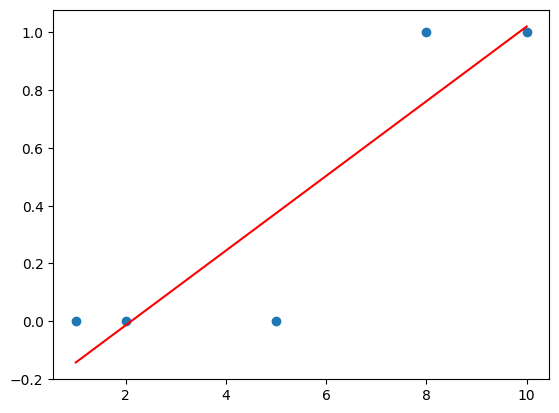

In [71]:
x = np.array([1,2,5,8,10])
y = np.array([0,0,0,1,1]) # 실제값
from scipy import stats
lm = stats.linregress(x,y) # 기울기(w)와 y절편(b)
H = lm[0]*x + lm[1]
import matplotlib.pyplot as plt
plt.plot(x, H, 'r')
plt.scatter(x,y)

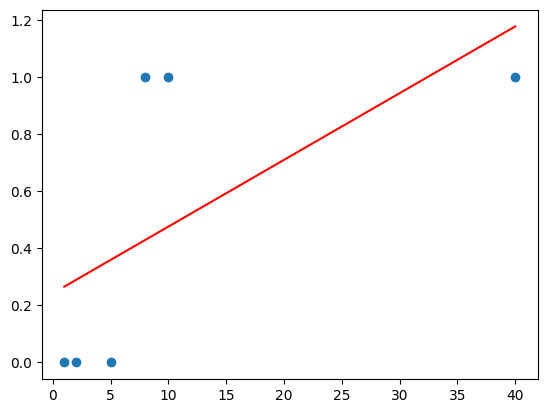

In [72]:
x = np.array([1,2,5,8,10,40])
y = np.array([0,0,0,1,1,1]) # 실제값
from scipy import stats
lm = stats.linregress(x,y) # 기울기(w)와 y절편(b)
H = lm[0]*x + lm[1]
import matplotlib.pyplot as plt
plt.plot(x, H, 'r')
plt.scatter(x,y)

In [89]:
# 교안 50page
import numpy as np
X_data = np.array([[10,0],
                   [8,1],
                   [3,3],
                   [2,3],
                   [5,1],
                   [2,0],
                   [1,0]])
y_data = np.array([[1],[1],[1],[1],[0],[0],[0],])

# tensorflow 구현 (tesor 그래프)
X = tf.placeholder(shape=[None,2], dtype=tf.float32)
y = tf.placeholder(shape=[None,1], dtype=tf.float32)
# 독립변수가 2개, 종속변수가 1개인 weight, bias
W = tf.Variable(tf.random.normal([2,1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis
logits = tf.matmul(X,W) + b
H      = tf.sigmoid(logits)
# cost함수
# cost = tf.reduce_mean(tf.square(H-y))
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,
                                                             labels=y))
# train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# sess객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer())
# 학습
for step in range(1, 8002):
    _, cost_val = sess.run([train,cost], feed_dict={X:X_data, y:y_data})
    if step%2000==1:
        print('{}번째 cost: {}'.format(step, cost_val))

1번째 cost: 4.168078899383545
2001번째 cost: 0.3466731607913971
4001번째 cost: 0.2674703896045685
6001번째 cost: 0.23289445042610168
8001번째 cost: 0.21179580688476562


In [90]:
# 모델 사용
input_data = np.array([[5, 2]])
predict = tf.cast(H>0.5, dtype=tf.float32)
sess.run(predict, feed_dict={X:input_data})

array([[1.]], dtype=float32)

In [92]:
# accuracy
correct = tf.equal(predict,y)
sess.run(correct, feed_dict={X:X_data, y:y_data})
accuracy = tf.reduce_mean(tf.cast(correct, dtype=tf.float32))
print('모델 정확도 :', sess.run(accuracy, feed_dict={X:X_data, y:y_data}))

모델 정확도 : 0.85714287


In [96]:
X_data = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_data = np.array([[0],[1],[1],[0]])
# X,y
X = tf.placeholder(shape=[None,2], dtype=tf.float32)
y = tf.placeholder(shape=[None,1], dtype=tf.float32)
# 독립변수가 2개, 종속변수가 1개 W,b
W = tf.Variable(tf.random.normal([2,1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis
logits = tf.matmul(X,W) + b
H      = tf.sigmoid(logits)
# cost함수
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,
                                                             labels=y))
# train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# sess객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer())
# 학습
for step in range(1, 10002):
    _, cost_val = sess.run([train,cost], feed_dict={X:X_data, y:y_data})
    if step%1000==1:
        print('{}번째 cost: {}'.format(step, cost_val))

1번째 cost: 1.3816784620285034
1001번째 cost: 0.7816638350486755
2001번째 cost: 0.7356628179550171
3001번째 cost: 0.71328204870224
4001번째 cost: 0.7024914622306824
5001번째 cost: 0.6974412202835083
6001번째 cost: 0.6951117515563965
7001번째 cost: 0.6940443515777588
8001번째 cost: 0.693556547164917
9001번째 cost: 0.6933339238166809
10001번째 cost: 0.6932324171066284


In [97]:
# accuracy
predict = tf.cast(H>0.5, dtype=tf.float32)
correct = tf.equal(predict,y)
sess.run(correct, feed_dict={X:X_data, y:y_data})
accuracy = tf.reduce_mean(tf.cast(correct, dtype=tf.float32))
print('모델 정확도 :', sess.run(accuracy, feed_dict={X:X_data, y:y_data}))

모델 정확도 : 0.75


# 5. Deep Learning XOR 예제

In [119]:
X_data = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_data = np.array([[0],[1],[1],[0]])
# X,y
X = tf.placeholder(shape=[None,2], dtype=tf.float32)
y = tf.placeholder(shape=[None,1], dtype=tf.float32)
# layer1: (입력2, 출력4) -> (2,2)로 줄이면?
W1 = tf.Variable(tf.random.normal([2,2]))
b1 = tf.Variable(tf.random.normal([2]))
# H
layer1 = tf.nn.relu(tf.matmul(X,W1) + b1)

# layer2: (입력4, 출력1) -> -> (2,1)로 줄여야
W2 = tf.Variable(tf.random.normal([2,1]))
b2 = tf.Variable(tf.random.normal([1]))
# H
logits = tf.matmul(layer1,W2) + b2
H = tf.sigmoid(logits)

# cost함수
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,
                                                             labels=y))
# train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# sess객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer())
# 학습
for step in range(1, 100002):
    _, cost_val = sess.run([train,cost], feed_dict={X:X_data, y:y_data})
    if step%10000==1:
        print('{}번째 cost: {}'.format(step, cost_val))

1번째 cost: 0.7450053095817566
10001번째 cost: 0.02265745773911476
20001번째 cost: 0.009573157876729965
30001번째 cost: 0.005934248678386211
40001번째 cost: 0.0042643179185688496
50001번째 cost: 0.0033139504957944155
60001번째 cost: 0.002703206380829215
70001번째 cost: 0.0022788087371736765
80001번째 cost: 0.001967510674148798
90001번째 cost: 0.0017294958233833313
100001번째 cost: 0.0015418081311509013


In [120]:
# accuracy
predict = tf.cast(H>0.5, dtype=tf.float32)
correct = tf.equal(predict,y)
sess.run(correct, feed_dict={X:X_data, y:y_data})
accuracy = tf.reduce_mean(tf.cast(correct, dtype=tf.float32))
print('모델 정확도 :', sess.run(accuracy, feed_dict={X:X_data, y:y_data}))

모델 정확도 : 1.0


## layer층 x_data 2개 -> 4 -> 1을
## layer층 x_data 2개 -> 10 -> 20 -> 10 -> 1

In [117]:
X_data = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_data = np.array([[0],[1],[1],[0]])
# X,y
X = tf.placeholder(shape=[None,2], dtype=tf.float32)
y = tf.placeholder(shape=[None,1], dtype=tf.float32)
# layer1: (입력2, 출력10)
W1 = tf.Variable(tf.random.normal([2,10]))
b1 = tf.Variable(tf.random.normal([10]))
# H
layer1 = tf.nn.relu(tf.matmul(X,W1) + b1)

# layer2: (입력10, 출력20)
W2 = tf.Variable(tf.random.normal([10,20]))
b2 = tf.Variable(tf.random.normal([20]))
# H
layer2 = tf.nn.relu(tf.matmul(layer1,W2) + b2)

# layer3: (입력20, 출력10)
W3 = tf.Variable(tf.random.normal([20,10]))
b3 = tf.Variable(tf.random.normal([10]))
# H
layer3 = tf.nn.relu(tf.matmul(layer2,W3) + b3)

# layer4: (입력10, 출력1)
W4 = tf.Variable(tf.random.normal([10,1]))
b4 = tf.Variable(tf.random.normal([1]))
# H : 출력층 이진분류에서는 sigmoid, 일반분류에서는 softmax
logits = tf.matmul(layer3,W4) + b4
H = tf.sigmoid(logits)

# cost함수
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,
                                                             labels=y))
# train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# sess객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer())
# 학습
for step in range(1, 5002):
    _, cost_val = sess.run([train,cost], feed_dict={X:X_data, y:y_data})
    if step%1000==1:
        print('{}번째 cost: {}'.format(step, cost_val))

1번째 cost: 0.6932324171066284
1001번째 cost: 0.6931642293930054
2001번째 cost: 0.6931565999984741
3001번째 cost: 0.6931537389755249
4001번째 cost: 0.6931521892547607
5001번째 cost: 0.6931512355804443


In [118]:
# accuracy
predict = tf.cast(H>0.5, dtype=tf.float32)
correct = tf.equal(predict,y)
sess.run(correct, feed_dict={X:X_data, y:y_data})
accuracy = tf.reduce_mean(tf.cast(correct, dtype=tf.float32))
print('모델 정확도 :', sess.run(accuracy, feed_dict={X:X_data, y:y_data}))

모델 정확도 : 0.5
